# **1. 개발 환경 구성**

In [1]:
!pip uninstall -y torch torchvision torchaudio torchtext torchdata
!pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2+cu118 --index-url https://download.pytorch.org/whl/cu118
!pip install torchtext==0.17.2
!pip install torchdata==0.7.1
!pip install portalocker==2.7.0

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchdata-0.11.0
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.1/819.1 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 125.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 97.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 56.8 MB/s eta 0:00:00
     ━━━━

seed고정


In [2]:
import random
import numpy as np
import torch

SEED = 1234

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# cuDNN 설정(완전한 결정성 모드)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fixed =", SEED)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

Seed fixed = 1234


## 2. 데이터셋 압축 해제 및 구조 분석

In [3]:
import os
import zipfile

# 업로드한 zip 파일 경로
zip_path = "/content/dataset-master.zip"

# 압축 해제
extract_path = "/content/dataset-master"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

extract_path


'/content/dataset-master'

In [4]:
import zipfile

zip_path = "/content/dataset-master.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist():
        print(name)


dataset-master/
dataset-master/.gitmodules
dataset-master/README.md
dataset-master/data/
dataset-master/data/task1/
dataset-master/data/task1/image_splits/
dataset-master/data/task1/image_splits/test_2016_flickr.txt
dataset-master/data/task1/image_splits/test_2017_flickr.txt
dataset-master/data/task1/image_splits/test_2017_mscoco.txt
dataset-master/data/task1/image_splits/test_2018_flickr.txt
dataset-master/data/task1/image_splits/train.txt
dataset-master/data/task1/image_splits/val.txt
dataset-master/data/task1/multi30k_test_sets_d3ec2a38.tar.gz
dataset-master/data/task1/pairs
dataset-master/data/task1/raw/
dataset-master/data/task1/raw/test_2016_flickr.cs.gz
dataset-master/data/task1/raw/test_2016_flickr.de.gz
dataset-master/data/task1/raw/test_2016_flickr.en.gz
dataset-master/data/task1/raw/test_2016_flickr.fr.gz
dataset-master/data/task1/raw/test_2017_flickr.de.gz
dataset-master/data/task1/raw/test_2017_flickr.en.gz
dataset-master/data/task1/raw/test_2017_flickr.fr.gz
dataset-maste

In [5]:
import os

BASE = "/content/dataset-master/data/task1/tok"

train_en = os.path.join(BASE, "train.lc.norm.tok.en")
train_de = os.path.join(BASE, "train.lc.norm.tok.de")

val_en   = os.path.join(BASE, "val.lc.norm.tok.en")
val_de   = os.path.join(BASE, "val.lc.norm.tok.de")

test_en  = os.path.join(BASE, "test_2016_flickr.lc.norm.tok.en")
test_de  = os.path.join(BASE, "test_2016_flickr.lc.norm.tok.de")

train_en, train_de, val_en, val_de, test_en, test_de


('/content/dataset-master/data/task1/tok/train.lc.norm.tok.en',
 '/content/dataset-master/data/task1/tok/train.lc.norm.tok.de',
 '/content/dataset-master/data/task1/tok/val.lc.norm.tok.en',
 '/content/dataset-master/data/task1/tok/val.lc.norm.tok.de',
 '/content/dataset-master/data/task1/tok/test_2016_flickr.lc.norm.tok.en',
 '/content/dataset-master/data/task1/tok/test_2016_flickr.lc.norm.tok.de')

## 📊 데이터셋 및 전처리

*   **데이터셋**: Multi30k (영-독)
    *   **학습 데이터**: 29000 문장 쌍
    *   **검증 데이터**: 1000 문장 쌍
    *   **테스트 데이터**: 1000 문장 쌍
*   **평균 문장 길이**: 10~20 단어
*   **도메인**: 이미지 캡션 (단순 문장)
*   **전처리**: `lowercasing`, `tokenizing`, `<sos>`, `<eos>` 추가
*   **Vocab size**:
    *   Source (English): 5921 단어
    *   Target (German): 7859 단어
    *   특징: 1번만 등장한 단어는 `<unk>` 토큰으로 처리, 특수 토큰(`<pad>`, `<sos>`, `<eos>`, `<unk>`) 포함

---

## ⚙️ 모델 학습 설정

*   **Embedding size**: 256
*   **Hidden size**: 512
*   **RNN 유형**: GRU
    *   인코더: 양방향 (Bidirectional)
    *   디코더: 단방향 (Unidirectional)
*   **Optimizer**: Adam (Learning Rate: 0.0005)
*   **Batch size**: 64
*   **Epoch**: 20
*   **Max sequence length**: 80
*   **Dropout**:
    *   인코더 Embedding: 0.5
    *   디코더 Embedding: 0.3
    *   어텐션: 0.1
*   **Attention**: Bahdanau (Additive)
*   **Loss Function**: CrossEntropyLoss (label_smoothing=0.1, ignore_index for `<pad>`)
*   **Teacher Forcing Ratio**: 에폭이 지남에 따라 1.0에서 0.1까지 감소 (1.0 - epoch * (1.0 / epochs))

# 3. 데이터 로딩

파일 로딩 함수 (EN–DE pair 불러오기)


In [6]:
def clean_eos(line):
    tokens = line.strip().split()
    if tokens and tokens[-1] == "<eos>":   # raw corpus <eos> 제거
        tokens = tokens[:-1]
    return " ".join(tokens)

def load_parallel_file(src_path, trg_path):
    with open(src_path, 'r', encoding='utf-8') as f:
        src_lines = f.read().splitlines()

    with open(trg_path, 'r', encoding='utf-8') as f:
        trg_lines = f.read().splitlines()

    assert len(src_lines) == len(trg_lines), "SRC와 TRG 문장 수가 다릅니다."

    # EOS 중복 제거 및 빈 문장 제거
    pairs = []
    for s, t in zip(src_lines, trg_lines):
        s_clean = clean_eos(s)
        t_clean = clean_eos(t)
        if s_clean.strip() != "" and t_clean.strip() != "":
            pairs.append((s_clean, t_clean))

    return pairs


## 4. 토크나이저 구성

In [7]:
def tokenize(text):
    return text.strip().split()


# 5. Vocabulary 구축
영어와 독일어를 하나의 vocab으로 묶음
13643개의 단어
1번만 등장한 단어들은 vocab 에 넣지 않음 -> unk토큰으로 처리


In [8]:
from collections import Counter

SPECIAL_TOKENS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def clean_eos(tokens):
    if tokens and tokens[-1] == "<eos>":
        return tokens[:-1]
    return tokens

def build_vocab_single(lines, min_freq=2):
    counter = Counter()

    for line in lines:
        tokens = tokenize(line)
        tokens = clean_eos(tokens)
        counter.update(tokens)

    vocab = {tok:i for i, tok in enumerate(SPECIAL_TOKENS)}
    idx = len(SPECIAL_TOKENS)

    for word, freq in counter.items():
        if freq >= min_freq and word not in vocab:
            vocab[word] = idx
            idx += 1

    return vocab

def build_vocabs(dataset, min_freq=2):
    src_lines = [src for src, _ in dataset]
    trg_lines = [trg for _, trg in dataset]

    src_vocab = build_vocab_single(src_lines, min_freq)
    trg_vocab = build_vocab_single(trg_lines, min_freq)

    print("SRC vocab size:", len(src_vocab))
    print("TRG vocab size:", len(trg_vocab))

    return src_vocab, trg_vocab


# 6. 문장을 숫자 시퀀스로 변환 (Encode Function)
최대 길이(max_len=80)

부족하면 pad 로 패딩

In [9]:
def encode_sentence(sentence, vocab, max_len=80):
    tokens = tokenize(sentence)

    # raw corpus 마지막이 <eos>라면 제거
    if tokens and tokens[-1] == "<eos>":
        tokens = tokens[:-1]

    # augmentation 적용 가능
    # tokens = augment_tokens(tokens)   # 원하면 활성화

    # <sos> + tokens + <eos> 붙이기
    tokens = ["<sos>"] + tokens + ["<eos>"]

    # max 길이 제한 — <eos>는 반드시 포함되게 커팅
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
        # 자른 후 마지막 토큰이 <eos>가 아니면 강제로 넣기
        if tokens[-1] != "<eos>":
            tokens[-1] = "<eos>"

    # 토큰 → ID 변환
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

    # pad
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))

    return ids


# 7. Custom Dataset 구현

In [10]:
from torch.utils.data import Dataset, DataLoader

def augment_tokens(tokens):
    # 예시: 랜덤 단어 드롭 (확률 10%)
    if len(tokens) > 5 and random.random() < 0.1:
        drop_idx = random.randint(0, len(tokens) - 1)
        tokens.pop(drop_idx)
    return tokens


class TranslationDataset(Dataset):
    def __init__(self, data, SRC_vocab, TRG_vocab, max_len=80, augment=False):
        self.data = data
        self.SRC_vocab = SRC_vocab
        self.TRG_vocab = TRG_vocab
        self.max_len = max_len
        self.augment = augment   # 🔥 augmentation 켜기

    def __getitem__(self, idx):
        src, trg = self.data[idx]

        # 🔥 augmentation 적용 (train만 True로 설정)
        if self.augment:
            src_tokens = augment_tokens(src.split())
            trg_tokens = augment_tokens(trg.split())
            src = " ".join(src_tokens)
            trg = " ".join(trg_tokens)

        src_ids = torch.tensor(encode_sentence(src, self.SRC_vocab, self.max_len))
        trg_ids = torch.tensor(encode_sentence(trg, self.TRG_vocab, self.max_len))

        return src_ids, trg_ids

    def __len__(self):
        return len(self.data)


# 8. DataLoader 구현

In [11]:
BASE = "/content/dataset-master/dataset-master/data/task1/tok"

train_data = load_parallel_file(
    f"{BASE}/train.lc.norm.tok.en",
    f"{BASE}/train.lc.norm.tok.de"
)

val_data = load_parallel_file(
    f"{BASE}/val.lc.norm.tok.en",
    f"{BASE}/val.lc.norm.tok.de"
)

test_data = load_parallel_file(
    f"{BASE}/test_2016_flickr.lc.norm.tok.en",
    f"{BASE}/test_2016_flickr.lc.norm.tok.de"
)

# 🔥 새 vocab builder 적용 (SRC/TRG 분리)
SRC_vocab, TRG_vocab = build_vocabs(train_data, min_freq=2)

print("SRC vocab size:", len(SRC_vocab))
print("TRG vocab size:", len(TRG_vocab))


SRC vocab size: 5921
TRG vocab size: 7859
SRC vocab size: 5921
TRG vocab size: 7859


DataLoader 준비


In [12]:
# ✅ 1) 여기서 Dataset 먼저 만들고
from torch.utils.data import DataLoader

train_dataset = TranslationDataset(
    train_data,
    SRC_vocab,
    TRG_vocab,
    max_len=80,
    augment=True       # 🔥 train에만 augmentation 켜기
)

val_dataset = TranslationDataset(
    val_data,
    SRC_vocab,
    TRG_vocab,
    max_len=80,
    augment=False
)

test_dataset = TranslationDataset(
    test_data,
    SRC_vocab,
    TRG_vocab,
    max_len=80,
    augment=False
)

In [13]:
# ✅ 2) 그 다음에 DataLoader + seed generator
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    generator=g
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    generator=g
)

#**Bahdanau Attention 모델**

# 1. Encoder 구현

In [14]:
import torch
import torch.nn as nn
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, dropout=0.5):
        super().__init__()

        self.hidden_size = hidden_size

        # Embedding + Dropout
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding_dropout = nn.Dropout(dropout)

        # Bi-GRU
        self.gru = nn.GRU(
            embed_size,
            hidden_size,
            bidirectional=True,
            batch_first=True
        )

        # forward + backward → decoder hidden projection
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x):
        # x: (batch, seq_len)

        # 1) embedding + dropout
        embedded = self.embedding_dropout(self.embedding(x))
        # (batch, seq_len, embed)

        # 2) Bi-GRU
        outputs, hidden = self.gru(embedded)
        # outputs: (batch, seq_len, hidden*2)
        # hidden: (2, batch, hidden)  (forward, backward)

        h_forward = hidden[-2, :, :]  # (batch, hidden)
        h_backward = hidden[-1, :, :] # (batch, hidden)

        # 3) concat → linear → tanh
        combined = torch.cat((h_forward, h_backward), dim=1)  # (batch, hidden*2)
        decoder_init_hidden = torch.tanh(self.fc(combined))

        return outputs, decoder_init_hidden


#Attention 교환


#Luong Dot Attention (Global)


In [153]:
import torch
import torch.nn as nn
import math

class LuongDotAttention(nn.Module):
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()
        self.query_proj = nn.Linear(hidden_size, hidden_size * 2, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_outputs, hidden, mask):
        """
        encoder_outputs: (B, S, 2H)
        hidden:          (B, H)
        mask:            (B, S)  PAD=0 / non-pad=1
        """
        # query: (B, 2H)
        query = self.query_proj(hidden)  # (B, 2H)

        # score = h_i · query
        # (B, S, 2H) @ (B, 2H, 1) -> (B, S, 1) -> (B, S)
        score = torch.bmm(encoder_outputs, query.unsqueeze(2)).squeeze(2)

        score = score.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(score, dim=1)              # (B, S)
        attn = self.dropout(attn).unsqueeze(2)          # (B, S, 1)

        context = torch.sum(attn * encoder_outputs, dim=1)  # (B, 2H)
        return context, attn


#Luong Local-m Attention

In [165]:
import torch
import torch.nn as nn

class LuongLocalMAttention(nn.Module):
    def __init__(self, hidden_size, window_size=7, dropout=0.1):
        super().__init__()
        assert window_size % 2 == 1, "window_size는 홀수 추천(중앙이 생기게)."
        self.query_proj = nn.Linear(hidden_size, hidden_size * 2, bias=False)  # (H) -> (2H)
        self.D = window_size // 2
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_outputs, hidden, mask, t):
        """
        encoder_outputs: (B, S, 2H)
        hidden:          (B, H)
        mask:            (B, S) PAD=0 / non-pad=1
        t:               int (디코더 타임스텝, 0..T-1)
        return:
            context: (B, 2H)
            attn:    (B, S, 1)  (heatmap용으로 전체 길이로 반환)
        """
        B, S, _ = encoder_outputs.size()

        # query (B, 2H)
        query = self.query_proj(hidden)

        # global score (B, S)
        score = torch.bmm(encoder_outputs, query.unsqueeze(2)).squeeze(2)

        # local-m: p_t = t, window [t-D, t+D]
        start = max(0, t - self.D)
        end   = min(S, t + self.D + 1)

        # window mask (B,S)
        wmask = torch.zeros_like(mask)
        wmask[:, start:end] = 1

        # PAD mask + window mask 적용
        valid = (mask == 1) & (wmask == 1)
        score = score.masked_fill(~valid, -1e9)

        # attention weights
        attn_1d = torch.softmax(score, dim=1)          # (B, S)
        attn_1d = self.dropout(attn_1d)

        # context
        context = torch.bmm(attn_1d.unsqueeze(1), encoder_outputs).squeeze(1)  # (B,2H)

        # heatmap 저장 편하게 (B,S,1)로
        attn = attn_1d.unsqueeze(2)
        return context, attn


#Scaled Dot-Product Attention

In [15]:
class ScaledDotAttention(nn.Module):
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()
        self.query_proj = nn.Linear(hidden_size, hidden_size * 2, bias=False)
        self.scale = math.sqrt(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_outputs, hidden, mask):
        """
        encoder_outputs: (B, S, 2H)
        hidden:          (B, H)
        mask:            (B, S)
        """
        query = self.query_proj(hidden)  # (B, 2H)

        score = torch.bmm(encoder_outputs, query.unsqueeze(2)).squeeze(2)
        score = score / self.scale

        score = score.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(score, dim=1)
        attn = self.dropout(attn).unsqueeze(2)          # (B, S, 1)

        context = torch.sum(attn * encoder_outputs, dim=1)
        return context, attn


# 2. Bahdanau Attention 구현

In [68]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()

        self.W1 = nn.Linear(hidden_size * 2, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.V  = nn.Linear(hidden_size, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_outputs, hidden, mask):
        """
        encoder_outputs: (batch, seq_len, hidden*2)
        hidden:          (batch, hidden)
        mask:            (batch, seq_len), PAD=0 / non-pad=1
        """

        # (batch, 1, hidden)
        hidden = hidden.unsqueeze(1)

        # additive attention score
        score = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        score = self.V(score).squeeze(-1)   # (batch, seq_len)

        # 🔥 mask 적용: PAD 위치는 -inf로
        score = score.masked_fill(mask == 0, -1e9)

        # softmax
        attention_weights = torch.softmax(score, dim=1)  # (batch, seq_len)
        attention_weights = attention_weights.unsqueeze(2)  # (batch, seq_len, 1)

        # attention dropout (optional but recommended)
        attention_weights = self.dropout(attention_weights)

        # context 계산
        context = torch.sum(attention_weights * encoder_outputs, dim=1)
        # (batch, hidden*2)

        return context, attention_weights


In [ ]:
print(f"Train dataset size: {len(train_data)} pairs")
print(f"Validation dataset size: {len(val_data)} pairs")
print(f"Test dataset size: {len(test_data)} pairs")

NameError: name 'train_data' is not defined

# 3. Decoder 구현

In [20]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size

        # target embedding + dropout
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding_dropout = nn.Dropout(dropout)

        # attention module
        # self.attention = BahdanauAttention(hidden_size)
        # self.attention = LuongDotAttention(hidden_size)
        self.attention = ScaledDotAttention(hidden_size)

        # GRU input = [embedding, context]
        self.gru = nn.GRU(
            embed_size + hidden_size * 2,
            hidden_size,
            batch_first=True
        )

        # output projection
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, encoder_outputs, mask):
        """
        x: (batch)
        hidden: (batch, hidden)
        encoder_outputs: (batch, seq_len, enc_hid*2)
        mask: (batch, seq_len)
        """

        # 1) embedding
        x = x.unsqueeze(1)                     # (batch, 1)
        embedded = self.embedding(x)           # (batch, 1, embed)
        embedded = self.embedding_dropout(embedded)

        # 2) Attention (now with mask!)
        context, attn = self.attention(encoder_outputs, hidden, mask)
        context = context.unsqueeze(1)         # (batch, 1, hidden*2)

        # 3) GRU input
        rnn_input = torch.cat([embedded, context], dim=-1)

        # 4) GRU step
        output, hidden = self.gru(rnn_input, hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)

        # 5) vocab logits
        output = self.fc(output.squeeze(1))    # (batch, vocab_size)

        return output, hidden, attn


#local attention용 디코더



In [167]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, dropout=0.3,
                 attention_type="local_m", window_size=7):
        super().__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding_dropout = nn.Dropout(dropout)

        if attention_type == "bahdanau":
            self.attention = BahdanauAttention(hidden_size)
        elif attention_type == "local_m":
            self.attention = LuongLocalMAttention(hidden_size, window_size=window_size)
        else:
            raise ValueError("unknown attention_type")

        self.gru = nn.GRU(embed_size + hidden_size * 2, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, encoder_outputs, mask, t=None):
        x = x.unsqueeze(1)
        embedded = self.embedding_dropout(self.embedding(x))

        # attention
        if t is None:
            context, attn = self.attention(encoder_outputs, hidden, mask)
        else:
            context, attn = self.attention(encoder_outputs, hidden, mask, t)

        context = context.unsqueeze(1)
        rnn_input = torch.cat([embedded, context], dim=-1)

        output, hidden = self.gru(rnn_input, hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)

        output = self.fc(output.squeeze(1))
        return output, hidden, attn


# 4. Seq2Seq Wrapper

In [21]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.pad_idx = pad_idx

    def create_mask(self, src):
        # src: (batch, seq_len)
        # mask: PAD=0, non-PAD=1
        return (src != self.pad_idx).int()

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)

        # 1) Encoder 실행
        encoder_outputs, hidden = self.encoder(src)

        # 2) Attention mask 생성
        src_mask = self.create_mask(src)  # (batch, seq_len)

        # 3) Decoder 첫 입력 = <sos>
        input_tok = trg[:, 0]

        for t in range(1, trg_len):

            # 4) Decoder step (mask 포함)
            output, hidden, attn = self.decoder(
                input_tok, hidden, encoder_outputs, src_mask
            )

            outputs[:, t] = output

            # 5) Teacher forcing
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_tok = trg[:, t] if teacher_force else top1

        return outputs

# 5. 모델 초기화

In [23]:
import math

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embed_size = 256
hidden_size = 512

# 🔥 vocab 분리했으므로 각각 크기 가져옴
SRC_vocab_size = len(SRC_vocab)
TRG_vocab_size = len(TRG_vocab)

pad_idx = TRG_vocab["<pad>"]   # decoder pad idx

# 🔥 Encoder는 SRC_vocab 사용 (영어)
encoder = Encoder(
    vocab_size=SRC_vocab_size,
    embed_size=embed_size,
    hidden_size=hidden_size
).to(device)

# 🔥 Decoder는 TRG_vocab 사용 (독일어)
decoder = Decoder(
    vocab_size=TRG_vocab_size,
    embed_size=embed_size,
    hidden_size=hidden_size
).to(device)

# 🔥 Seq2Seq 만들 때 pad_idx 전달해야 mask가 동작함
model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=device,
    pad_idx=pad_idx
).to(device)


# 6. Loss + Optimizer

In [25]:
# 🔥 반드시 TRG_vocab에서 pad index 가져와야 함
pad_idx = TRG_vocab["<pad>"]

criterion = nn.CrossEntropyLoss(
    ignore_index=TRG_vocab["<pad>"],  # PAD는 여전히 무시
    label_smoothing=0.1               # 🔥 여기만 추가
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)


#**Training**

# 1. Training & Evaluation 함수

In [26]:
def train_one_epoch(model, train_loader, optimizer, criterion, device, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0

    for batch_idx, (src, trg) in enumerate(train_loader):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        # forward pass (mask-aware)
        output = model(src, trg, teacher_forcing_ratio)
        # output: (batch, seq_len, vocab)

        output_dim = output.shape[-1]

        # trg[:,1:] = next tokens
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        optimizer.step()
        epoch_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    return epoch_loss / len(train_loader)


In [27]:
def evaluate(model, val_loader, criterion, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in val_loader:
            src = src.to(device)
            trg = trg.to(device)

            # teacher forcing = 0 during evaluation
            output = model(src, trg, teacher_forcing_ratio=0.0)

            # output: (batch, seq_len, vocab)
            output_dim = output.shape[-1]

            # Shift both output and target to ignore <sos>
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(val_loader)


# 2. 전체 학습 루프

In [28]:
import time
import math
import torch

def run_training(model, train_loader, val_loader, optimizer, criterion, device,
                 epochs=10, checkpoint_path="sclaed_dot_attention_model.pt"):

    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        start = time.time()

        # 🔥 teacher forcing ratio 감소
        teacher_forcing_ratio = max(0.1, 1.0 - epoch * (1.0 / epochs))
        print(f"Teacher Forcing Ratio: {teacher_forcing_ratio:.3f}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            teacher_forcing_ratio=teacher_forcing_ratio
        )

        val_loss = evaluate(model, val_loader, criterion, device)

        end = time.time()

        print(f"Epoch {epoch}/{epochs}")
        print(f"  - Train Loss: {train_loss:.4f} | PPL: {math.exp(train_loss):.2f}")
        print(f"  - Val   Loss: {val_loss:.4f} | PPL: {math.exp(val_loss):.2f}")
        print(f"  - Time Spent: {end - start:.2f}s")
        print("-----------------------------------")

        # 🔥 checkpoint 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  ✅ Model saved to {checkpoint_path} (Validation Loss improved to {best_val_loss:.4f})")


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. 학습

In [31]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("⚠ CPU에서 연산 중 → 매우 느림")

# ============================
# 🔥 Forward sanity check
# ============================
model.eval()
with torch.no_grad():
    for i, (src, trg) in enumerate(train_loader):
        src = src.to(device)
        trg = trg.to(device)

        print("Batch loaded:", src.shape, trg.shape)

        # mask-aware Seq2Seq forward
        output = model(src, trg, teacher_forcing_ratio=1.0)

        print("Forward OK! Output shape:", output.shape)
        # Expect shape: (batch, seq_len, TRG_vocab_size)
        break

CUDA available: True
GPU name: NVIDIA A100-SXM4-80GB
Batch loaded: torch.Size([64, 80]) torch.Size([64, 80])
Forward OK! Output shape: torch.Size([64, 80, 7859])


In [32]:
EPOCHS = 20  # 원하는 만큼 조절 가능

run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS
)


Teacher Forcing Ratio: 0.950
  Batch 10/454 | Loss: 6.5566
  Batch 20/454 | Loss: 5.7164
  Batch 30/454 | Loss: 5.6715
  Batch 40/454 | Loss: 5.6119
  Batch 50/454 | Loss: 5.5576
  Batch 60/454 | Loss: 5.5879
  Batch 70/454 | Loss: 5.3166
  Batch 80/454 | Loss: 5.3881
  Batch 90/454 | Loss: 5.2935
  Batch 100/454 | Loss: 5.2249
  Batch 110/454 | Loss: 5.1817
  Batch 120/454 | Loss: 4.9509
  Batch 130/454 | Loss: 4.9418
  Batch 140/454 | Loss: 5.0087
  Batch 150/454 | Loss: 5.0686
  Batch 160/454 | Loss: 4.8554
  Batch 170/454 | Loss: 4.8727
  Batch 180/454 | Loss: 4.7870
  Batch 190/454 | Loss: 4.9049
  Batch 200/454 | Loss: 4.6578
  Batch 210/454 | Loss: 4.5758
  Batch 220/454 | Loss: 4.6908
  Batch 230/454 | Loss: 4.5815
  Batch 240/454 | Loss: 4.4169
  Batch 250/454 | Loss: 4.5096
  Batch 260/454 | Loss: 4.6840
  Batch 270/454 | Loss: 4.6281
  Batch 280/454 | Loss: 4.3411
  Batch 290/454 | Loss: 4.5691
  Batch 300/454 | Loss: 4.6316
  Batch 310/454 | Loss: 4.3997
  Batch 320/454 | L

# 4. Model Load

In [36]:
# ------------------------------------------
# 모델 로드 (학습이 끝난 후)
# ------------------------------------------
checkpoint_path = "/content/sclaed_dot_attention_model.pt" #학습후에 이름 바꾸기

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # 평가 모드로 전환
print("✅ 학습된 모델 로드 완료!")

# ------------------------------------------
# 로드 직후 pt파일 자동 다운로드
# ------------------------------------------
from google.colab import files
files.download(checkpoint_path)   # 자동 다운로드


✅ 학습된 모델 로드 완료!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#local attention

In [37]:
import torch

def translate_beam_search(model, sentence, SRC_vocab, TRG_vocab, device,
                          max_len=80, beam_size=10):
    model.eval()

    tokens = ["<sos>"] + sentence.lower().strip().split() + ["<eos>"]
    src_ids = [SRC_vocab.get(tok, SRC_vocab["<unk>"]) for tok in tokens]

    if len(src_ids) < max_len:
        src_ids += [SRC_vocab["<pad>"]] * (max_len - len(src_ids))
    else:
        src_ids = src_ids[:max_len]

    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # (1, max_len)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    src_mask = (src_tensor != SRC_vocab["<pad>"]).int()

    sos = TRG_vocab["<sos>"]
    eos = TRG_vocab["<eos>"]

    # (logp, hidden, seq)
    beams = [(0.0, hidden, [sos])]
    completed = []

    for _ in range(max_len):
        new_beams = []

        for log_prob, h, seq in beams:
            last_tok = seq[-1]

            if last_tok == eos:
                completed.append((log_prob, h, seq))
                continue

            trg_last = torch.tensor([last_tok]).to(device)

            # ✅ Local-m은 t 필요: 현재까지 생성한 길이-1 (=첫 출력이 t=0)
            t = len(seq) - 1

            with torch.no_grad():
                output, h_new, attn = model.decoder(
                    trg_last, h, encoder_outputs, src_mask, t=t
                )

            # ✅ Beam score는 log_softmax 쓰는 게 정석
            logp_step = torch.log_softmax(output, dim=1)  # (1, vocab)

            topk = torch.topk(logp_step, beam_size)
            probs = topk.values.squeeze(0)   # (beam_size,)
            idxs  = topk.indices.squeeze(0)  # (beam_size,)

            for p, idx in zip(probs, idxs):
                new_seq = seq + [idx.item()]
                new_log_prob = log_prob + float(p)
                new_beams.append((new_log_prob, h_new, new_seq))

        if not new_beams:
            break

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]

        if len(completed) >= beam_size:
            break

    if completed:
        best = sorted(completed, key=lambda x: x[0], reverse=True)[0]
    else:
        best = beams[0]

    _, _, seq = best  # ✅ 3개짜리로 통일했으니 이렇게

    id2word = {v: k for k, v in TRG_vocab.items()}
    pred_tokens = []
    for idx in seq[1:]:
        if idx == eos:
            break
        pred_tokens.append(id2word.get(idx, "<unk>"))

    return " ".join(pred_tokens)


#dot종류

In [45]:
def translate_beam_search(model, sentence, SRC_vocab, TRG_vocab, device,
                          max_len=80, beam_size=10):
    model.eval()

    tokens = sentence.lower().strip().split()
    tokens = ["<sos>"] + tokens + ["<eos>"]

    src_ids = [SRC_vocab.get(tok, SRC_vocab["<unk>"]) for tok in tokens]
    if len(src_ids) < max_len:
        src_ids += [SRC_vocab["<pad>"]] * (max_len - len(src_ids))
    else:
        src_ids = src_ids[:max_len]

    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    src_mask = (src_tensor != SRC_vocab["<pad>"]).int()

    beams = [(0.0, hidden, [TRG_vocab["<sos>"]], [])] # Add empty list for attention history
    completed = []

    for t_step in range(max_len):
        new_beams = []

        for log_prob, h, seq, attn_hist in beams:
            last_tok = seq[-1]
            if last_tok == TRG_vocab["<eos>"]:
                completed.append((log_prob, h, seq, attn_hist))

                continue

            trg_last = torch.tensor([last_tok]).to(device)

            with torch.no_grad():
                output, h_new, attn = model.decoder(
                    trg_last, h, encoder_outputs, src_mask,
                )

            topk = torch.topk(output, beam_size)
            probs = topk.values.squeeze(0)
            idxs  = topk.indices.squeeze(0)

            attn_row = attn[0] # Get attention for the current batch item
            if attn_row.dim() == 2: # Handle (seq_len, 1) case for attention
                attn_row = attn_row.squeeze(-1)
            new_attn_hist = attn_hist + [attn_row.detach().cpu()] # Store attention

            for p, idx in zip(probs, idxs):
                new_seq = seq + [idx.item()]
                new_log_prob = log_prob + float(p)
                new_beams.append((new_log_prob, h_new, new_seq, new_attn_hist))

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]

        if len(completed) >= beam_size:
            break

    if completed:
        best = sorted(completed, key=lambda x: x[0], reverse=True)[0]
    else:
        best = beams[0]

    best_logp, best_hidden, seq, attn_hist = best

    id2word = {v: k for k, v in TRG_vocab.items()}
    pred_tokens = []
    for idx in seq[1:]:
        if idx == TRG_vocab["<eos>"]:
            break
        pred_tokens.append(id2word[idx])

    return " ".join(pred_tokens)

In [39]:
print(type(model.decoder.attention))
print(model.decoder.attention)


<class '__main__.ScaledDotAttention'>
ScaledDotAttention(
  (query_proj): Linear(in_features=512, out_features=1024, bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [46]:
# 테스트셋 앞 5개 문장 sample 번역 보기
for i in range(5):
    src, trg = test_data[i]
    pred = translate_beam_search(model, src, SRC_vocab, TRG_vocab, device)

    print(f"[Source]      {src}")
    print(f"[Prediction]  {pred}")
    print(f"[Target]      {trg}")
    print("-" * 60)


[Source]      a man in an orange hat starring at something .
[Prediction]  ein mann mit orangefarbener mütze starrt auf etwas etwas .
[Target]      ein mann mit einem orangefarbenen hut , der etwas anstarrt .
------------------------------------------------------------
[Source]      a boston terrier is running on lush green grass in front of a white fence .
[Prediction]  ein <unk> rennt auf einer grünen gras vor einem weißen zaun .
[Target]      ein boston terrier läuft über saftig-grünes gras vor einem weißen zaun .
------------------------------------------------------------
[Source]      a girl in karate uniform breaking a stick with a front kick .
[Prediction]  ein mädchen in karateanzug kostümen einen stock mit einem korb . .
[Target]      ein mädchen in einem karateanzug bricht ein brett mit einem tritt .
------------------------------------------------------------
[Source]      five people wearing winter jackets and helmets stand in the snow , with snowmobiles in the background 

#BLUE계산


In [47]:
!wget https://raw.githubusercontent.com/moses-smt/mosesdecoder/master/scripts/generic/multi-bleu.perl
!chmod +x multi-bleu.perl


--2025-12-16 19:07:32--  https://raw.githubusercontent.com/moses-smt/mosesdecoder/master/scripts/generic/multi-bleu.perl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5234 (5.1K) [text/plain]
Saving to: ‘multi-bleu.perl’

multi-bleu.perl     100%[===================>]   5.11K  --.-KB/s    in 0s      

2025-12-16 19:07:32 (86.0 MB/s) - ‘multi-bleu.perl’ saved [5234/5234]



In [49]:
# test reference 파일 생성 (논문 방식: 각 줄에 한 문장)
with open("reference.txt", "w", encoding="utf-8") as f:
    for _, trg in test_data:
        f.write(trg.strip() + "\n")

print("reference.txt 생성 완료!")

with open("pred.txt", "w", encoding="utf-8") as f:
    for src, _ in test_data:
        pred = translate_beam_search(model, src, SRC_vocab, TRG_vocab, device)  # ← 변경됨
        f.write(pred.strip() + "\n")

print("pred.txt 생성 완료!")


reference.txt 생성 완료!
pred.txt 생성 완료!


In [50]:
!./multi-bleu.perl reference.txt < pred.txt

BLEU = 29.30, 60.8/36.4/22.8/14.6 (BP=1.000, ratio=1.039, hyp_len=12574, ref_len=12103)
It is not advisable to publish scores from multi-bleu.perl.  The scores depend on your tokenizer, which is unlikely to be reproducible from your paper or consistent across research groups.  Instead you should detokenize then use mteval-v14.pl, which has a standard tokenization.  Scores from multi-bleu.perl can still be used for internal purposes when you have a consistent tokenizer.


In [51]:
# BLEU 평가용 reference / hypothesis 생성 (외부 스크립트에서 사용)
with open("reference.txt", "w", encoding="utf-8") as f:
    for _, trg in test_data:
        f.write(trg.strip() + "\n")
print("reference.txt 생성 완료")

with open("hypothesis.txt", "w", encoding="utf-8") as f:
    for src, _ in test_data:
        pred = translate_beam_search(model, src, SRC_vocab, TRG_vocab, device)
        f.write(pred.strip() + "\n")
print("hypothesis.txt 생성 완료")

import zipfile

zip_path = "bleu_eval.zip"
with zipfile.ZipFile(zip_path, "w") as zipf:
    zipf.write("reference.txt")
    zipf.write("hypothesis.txt")

print("ZIP 생성 완료:", zip_path)

from google.colab import files
files.download("bleu_eval.zip")


reference.txt 생성 완료


KeyboardInterrupt: 

In [52]:
def select_sentences_for_alignment(
    test_data, SRC_vocab, num_sentences=4,
    min_len=10, max_len=20, seed=1234
):
    random.seed(seed)

    filtered = []
    unk_id = SRC_vocab["<unk>"]

    for src, trg in test_data:
        tokens = src.lower().strip().split()
        ids = [SRC_vocab.get(tok, unk_id) for tok in tokens]

        if min_len <= len(tokens) <= max_len and unk_id not in ids:
            filtered.append((src, trg))

    if len(filtered) < num_sentences:
        num_sentences = len(filtered)

    return random.sample(filtered, num_sentences)


#local용

In [210]:
import torch

def translate_beam_with_attention(
    model, sentence, SRC_vocab, TRG_vocab, device,
    beam_size=5, max_len=80
):
    model.eval()

    # 1) 소스 토큰화 + 패딩
    tokens = ["<sos>"] + sentence.lower().strip().split() + ["<eos>"]
    src_ids = [SRC_vocab.get(tok, SRC_vocab["<unk>"]) for tok in tokens]

    if len(src_ids) < max_len:
        src_ids += [SRC_vocab["<pad>"]] * (max_len - len(src_ids))
    else:
        src_ids = src_ids[:max_len]

    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # (1, max_len)
    src_mask = (src_tensor != SRC_vocab["<pad>"]).int()         # (1, max_len)

    # 2) 인코더
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    sos = TRG_vocab["<sos>"]
    eos = TRG_vocab["<eos>"]

    # beams: (logp, hidden, seq_ids, attn_hist[list of (S,)])
    beams = [(0.0, hidden, [sos], [])]
    completed = []

    # 3) 빔서치 디코딩
    for _ in range(max_len):
        new_beams = []

        for logp, h, seq, attn_hist in beams:
            last_tok = seq[-1]

            if last_tok == eos:
                completed.append((logp, h, seq, attn_hist))
                continue

            trg_tensor = torch.tensor([last_tok]).to(device)  # (1,)

            # ✅ Local-m: beam별 현재 디코딩 step
            t = len(seq) - 1   # 첫 예측이 t=0

            with torch.no_grad():
                output, h_new, attn = model.decoder(
                    trg_tensor, h, encoder_outputs, src_mask, t=t
                )

            # ✅ beam score는 log_softmax로 누적
            logp_step = torch.log_softmax(output, dim=1)

            topk = torch.topk(logp_step, beam_size)
            probs = topk.values.squeeze(0)
            idxs  = topk.indices.squeeze(0)

            # attn: (B,S,1) -> (S,)
            attn_row = attn[0]
            if attn_row.dim() == 2:
                attn_row = attn_row.squeeze(-1)
            attn_row = attn_row.detach().cpu()

            for p, idx in zip(probs, idxs):
                new_seq = seq + [idx.item()]
                new_logp = logp + float(p)
                new_attn_hist = attn_hist + [attn_row]
                new_beams.append((new_logp, h_new, new_seq, new_attn_hist))

        if not new_beams:
            break

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]

        if len(completed) >= beam_size:
            break

    # 4) best 선택
    if completed:
        best = sorted(completed, key=lambda x: x[0], reverse=True)[0]
    else:
        best = beams[0]

    best_logp, best_hidden, seq, attn_hist = best

    # 5) 토큰 디코딩
    id2word = {v: k for k, v in TRG_vocab.items()}
    pred_tokens = []
    for idx in seq[1:]:
        if idx == eos:
            break
        pred_tokens.append(id2word.get(idx, "<unk>"))

    # 6) attention matrix: (tgt_len, src_len)
    if len(attn_hist) > 0:
        attention_matrix = torch.stack(attn_hist, dim=0)  # (tgt_len, S)
    else:
        attention_matrix = torch.zeros(1, src_tensor.size(1))

    clean_src_tokens = tokens[1:-1]  # <sos>, <eos> 제거
    src_len = len(clean_src_tokens)

    # ✅ x축 라벨과 맞추기: <sos> 제외하고 자르기
    attention_matrix = attention_matrix[:, 1:1 + src_len]

    # ✅ EOS 제외한 실제 출력 길이만큼만 자르기(라벨 안 겹치게)
    attention_matrix = attention_matrix[:len(pred_tokens), :]

    return pred_tokens, clean_src_tokens, attention_matrix


#dot용


In [53]:
import torch

def translate_beam_with_attention(
    model, sentence, SRC_vocab, TRG_vocab, device,
    beam_size=5, max_len=80
):
    model.eval()

    # 1) 소스 토큰화 + 패딩
    tokens = ["<sos>"] + sentence.lower().strip().split() + ["<eos>"]
    src_ids = [SRC_vocab.get(tok, SRC_vocab["<unk>"]) for tok in tokens]

    if len(src_ids) < max_len:
        src_ids += [SRC_vocab["<pad>"]] * (max_len - len(src_ids))
    else:
        src_ids = src_ids[:max_len]

    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # (1, max_len)
    src_mask = (src_tensor != SRC_vocab["<pad>"]).int()         # (1, max_len)

    # 2) 인코더
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    sos = TRG_vocab["<sos>"]
    eos = TRG_vocab["<eos>"]

    # beams: (logp, hidden, seq_ids, attn_hist[list of (S,)])
    beams = [(0.0, hidden, [sos], [])]
    completed = []

    # 3) 빔서치 디코딩
    for _ in range(max_len):
        new_beams = []

        for logp, h, seq, attn_hist in beams:
            last_tok = seq[-1]

            if last_tok == eos:
                completed.append((logp, h, seq, attn_hist))
                continue

            trg_tensor = torch.tensor([last_tok]).to(device)  # (1,)

            with torch.no_grad():
                output, h_new, attn = model.decoder(trg_tensor, h, encoder_outputs, src_mask)

            # attn: (B,S,1) or (B,S) -> (S,)
            attn_row = attn[0]
            if attn_row.dim() == 2:
                attn_row = attn_row.squeeze(-1)
            attn_row = attn_row.detach().cpu()  # (S,)

            topk = torch.topk(output, beam_size)
            probs = topk.values.squeeze(0)
            idxs  = topk.indices.squeeze(0)

            for p, idx in zip(probs, idxs):
                new_seq = seq + [idx.item()]
                new_logp = logp + float(p)
                new_attn_hist = attn_hist + [attn_row]
                new_beams.append((new_logp, h_new, new_seq, new_attn_hist))

        if not new_beams:
            break

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]

        if len(completed) >= beam_size:
            break

    # 4) best 선택
    if completed:
        best = sorted(completed, key=lambda x: x[0], reverse=True)[0]
    else:
        best = beams[0]

    best_logp, best_hidden, seq, attn_hist = best

    # 5) 토큰 디코딩
    id2word = {v: k for k, v in TRG_vocab.items()}
    pred_tokens = []
    for idx in seq[1:]:
        if idx == eos:
            break
        pred_tokens.append(id2word.get(idx, "<unk>"))

    # 6) attention matrix 만들기: (tgt_len, src_len)
    if len(attn_hist) > 0:
        attention_matrix = torch.stack(attn_hist, dim=0)  # (tgt_len, S)
    else:
        attention_matrix = torch.zeros(1, src_tensor.size(1))

    clean_src_tokens = tokens[1:-1]   # <sos>, <eos> 제거
    src_len = len(clean_src_tokens)

    # <sos> (index 0)를 제외하고 그 다음부터 src_len개만 사용
    attention_matrix = attention_matrix[:, 1:1+src_len]

    return pred_tokens, clean_src_tokens, attention_matrix


In [54]:
import matplotlib.pyplot as plt

def plot_beam_attention(model, sentence, SRC_vocab, TRG_vocab, device):
    pred_tokens, src_tokens, attn_matrix = translate_beam_with_attention(
        model, sentence, SRC_vocab, TRG_vocab, device
    )

    attn = attn_matrix.detach().cpu().tolist()

    plt.figure(figsize=(10, 6))
    plt.imshow(attn, cmap="gray", interpolation="nearest")

    plt.xticks(range(len(src_tokens)), src_tokens, rotation=90, ㅁfontsize=8)
    plt.yticks(range(len(pred_tokens)), pred_tokens, fontsize=8)

    plt.title("Beam Search Attention Alignment (scaled_dot__attention)")
    plt.tight_layout()
    plt.show()


In [55]:
def plot_beam_attention_grid(model, sentences, SRC_vocab, TRG_vocab, device,
                             filename="paper_style_scaled_dot__attention.png"):

    n = len(sentences)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

    if n == 1:
        axes = [axes]

    for i, (src, trg) in enumerate(sentences):

        pred_tokens, src_tokens, attn_matrix = translate_beam_with_attention(
            model, src, SRC_vocab, TRG_vocab, device
        )

        attn = attn_matrix.detach().cpu().tolist()

        ax = axes[i]
        ax.imshow(attn, cmap="gray", interpolation="nearest")

        ax.set_xticks(range(len(src_tokens)))
        ax.set_xticklabels(src_tokens, rotation=90, fontsize=7)

        ax.set_yticks(range(len(pred_tokens)))
        ax.set_yticklabels(pred_tokens, fontsize=7)

        ax.set_title(f"Example {i+1}", fontsize=12)
        ax.tick_params(axis='both', which='both', length=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


In [57]:
model.load_state_dict(torch.load("sclaed_dot_attention_model.pt", map_location=device))
model.eval()


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(5921, 256)
    (embedding_dropout): Dropout(p=0.5, inplace=False)
    (gru): GRU(256, 512, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(7859, 256)
    (embedding_dropout): Dropout(p=0.3, inplace=False)
    (attention): ScaledDotAttention(
      (query_proj): Linear(in_features=512, out_features=1024, bias=False)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (gru): GRU(1280, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=7859, bias=True)
  )
)

선택된 문장들:
 - a man in an orange hat starring at something .
 - a boston terrier is running on lush green grass in front of a white fence .
 - a girl in karate uniform breaking a stick with a front kick .
 - five people wearing winter jackets and helmets stand in the snow , with snowmobiles in the background .


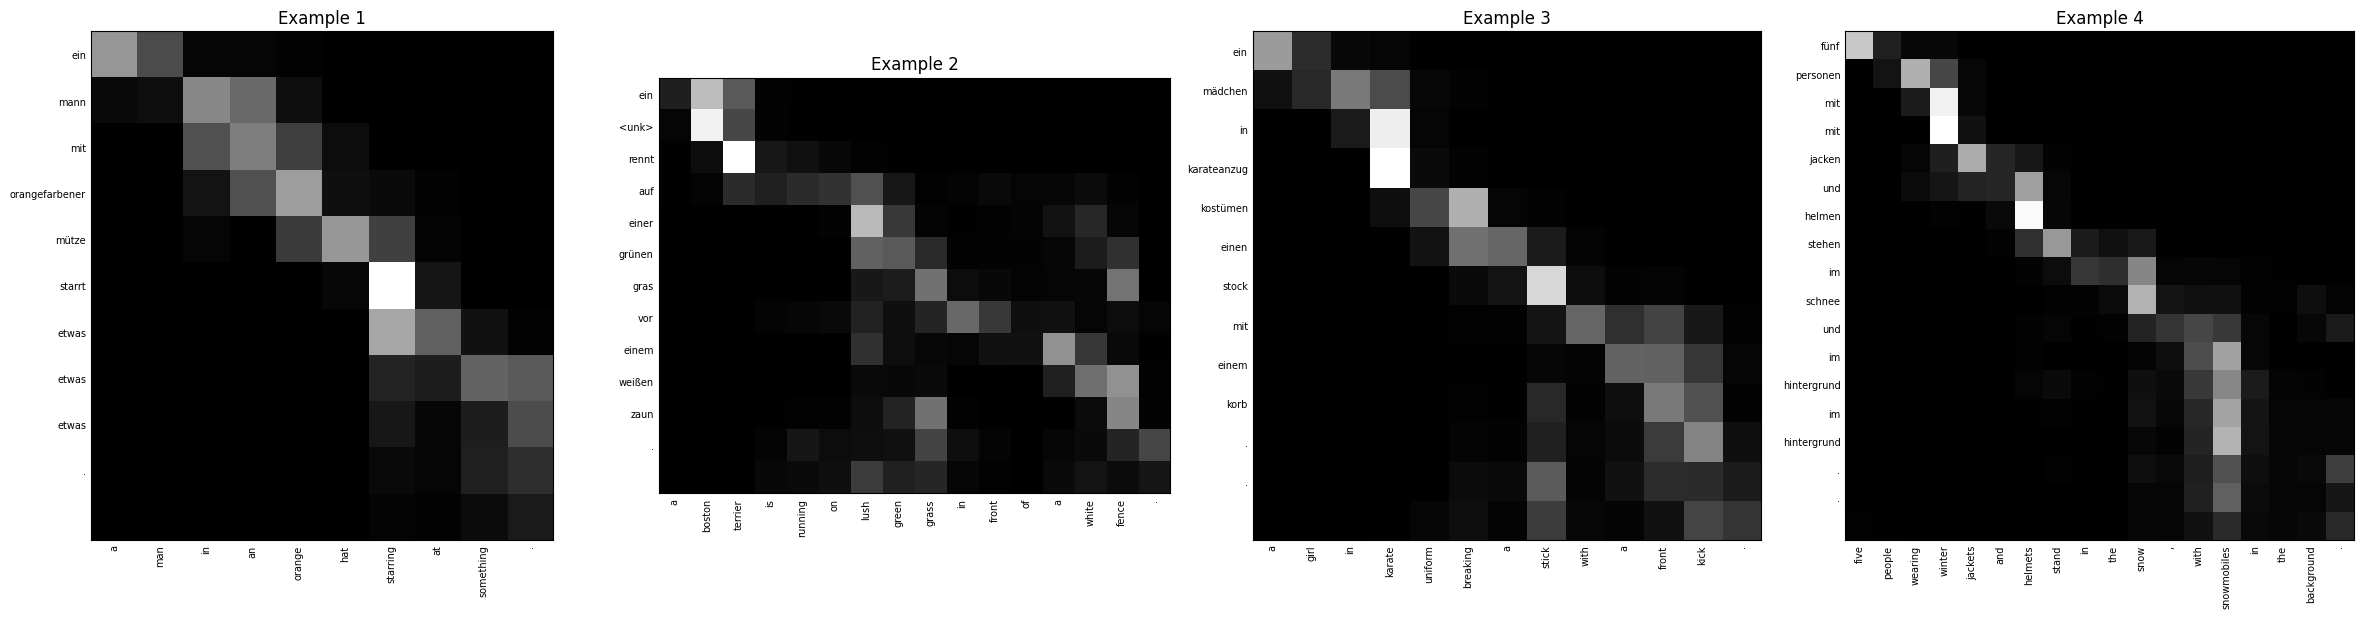

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# ------------------------------------------
# 1) 테스트셋 앞에서 N개 고정으로 뽑기 (논문 Figure 3용)
#    - 랜덤 X, seed X : 그냥 인덱스로 고정
# ------------------------------------------
N = 4   # Figure 3처럼 4개만 쓰고 싶으면 4, 5개 다 보고 싶으면 5로 변경

sentences = []   # (src, trg) 튜플 저장

print("선택된 문장들:")
for i in range(N):
    src, trg = test_data[i]
    sentences.append((src, trg))
    print(f" - {src}")

# ------------------------------------------
# 2) Beam Search 기반 Attention Grid 그리기
# ------------------------------------------
plot_beam_attention_grid(model, sentences, SRC_vocab, TRG_vocab, device)

# ------------------------------------------
# 3) 이미지 다운로드 (Colab)
# ------------------------------------------
from google.colab import files
files.download("paper_style_scaled_dot__attention.png")


선택된 문장들:
 - a child is laying on the ground next to a stroller .
 - this is a group of people standing around at some sort of event .
 - a woman holding a bowl of food in a kitchen .
 - a family going for a walk in a park .


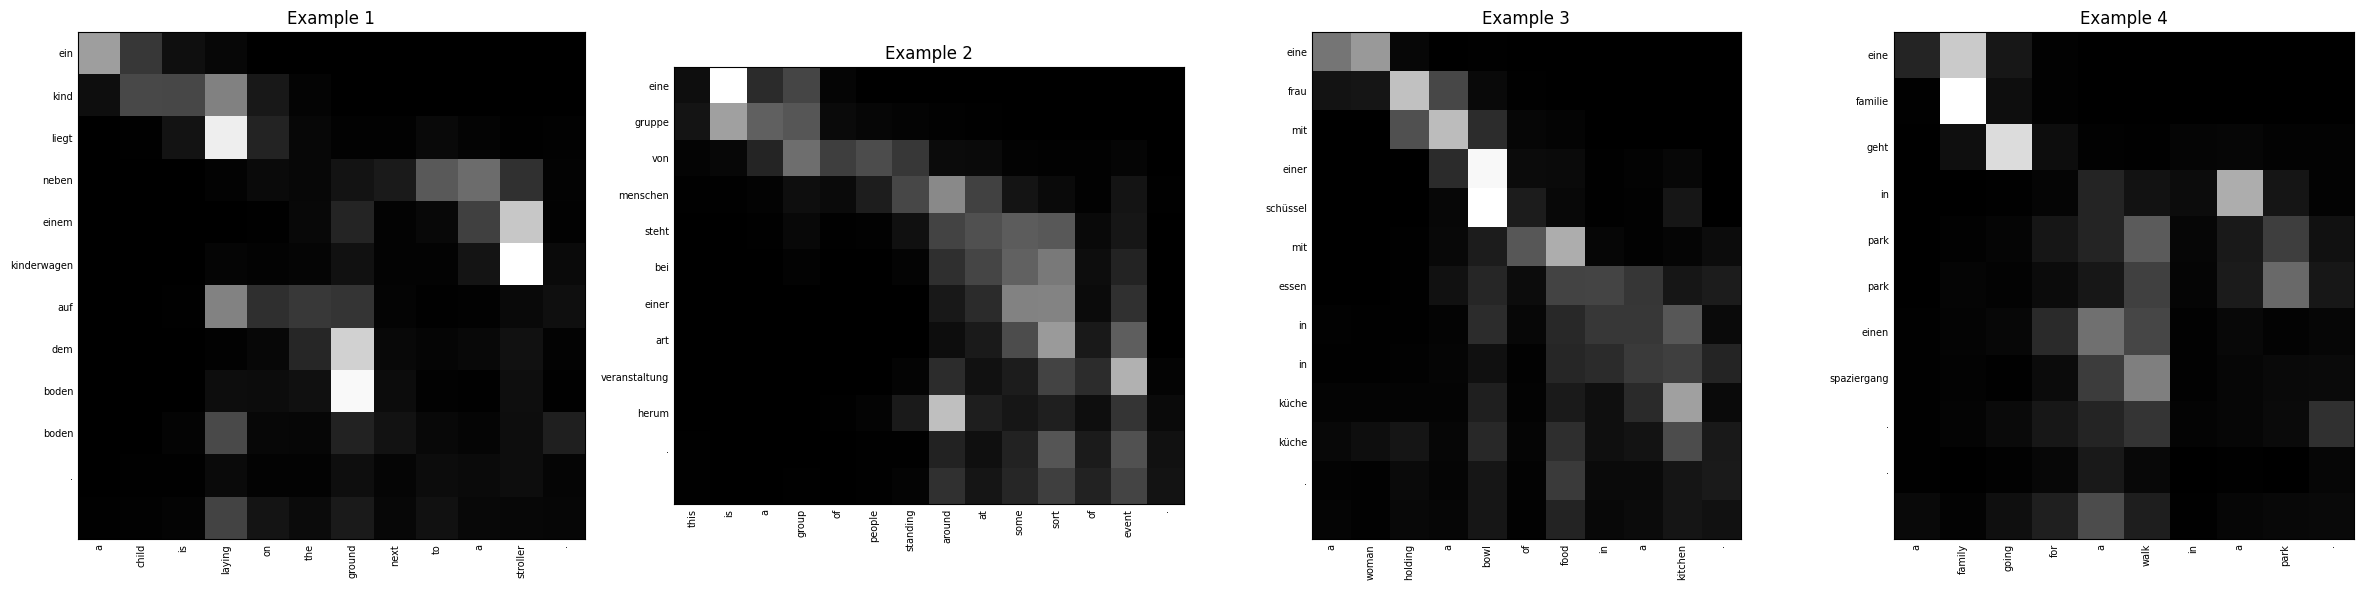

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# 1) 논문 조건에 맞게 testset에서 4개 선택 (seed 고정)
sentences = select_sentences_for_alignment(
    test_data, SRC_vocab,
    num_sentences=4,
    seed=1234
)

print("선택된 문장들:")
for src, trg in sentences:
    print(" -", src)

# 2) Figure 3 스타일 attention grid
plot_beam_attention_grid(model, sentences, SRC_vocab, TRG_vocab, device)

# 3) 이미지 다운로드 (Colab)
from google.colab import files
files.download("paper_style_scaled_dot__attention.png")
